#**QR-code ссылка на репозиторий в [Github](https://github.com/kubenet/ML_course)**

# Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович

---

---

# Практика №4: Регуляризация, Переобучение и Отбор Признаков

## 🎯 Цели занятия
1.  Изучить эффект переобучения на примере полиномиальной регрессии.
2.  Понять разницу между $L_1$ (Lasso) и $L_2$ (Ridge) регуляризацией.
3.  Научиться подбирать гиперпараметры через кросс-валидацию.
4.  Проанализировать устойчивость отбора признаков на реальных данных.

---

## 📚 Теоретический блок 1:Bias-Variance Tradeoff и Полиномиальная регрессия

**Концепция:**
Модель машинного обучения стремится минимизировать ошибку обобщения. Она складывается из:
$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error} $$

*   **Низкая степень полинома:** Высокое смещение (Bias), модель слишком простая (недообучение).
*   **Высокая степень полинома:** Высокая дисперсия (Variance), модель подстраивается под шум (переобучение).

**Регуляризация:**
Чтобы контролировать сложность модели, мы добавляем штрафной член к функции потерь (Loss Function):
*   **Ridge ($L_2$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} \theta_j^2$. Сжимает веса, но не обнуляет их.
*   **Lasso ($L_1$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} |\theta_j|$. Может обнулять веса, выполняя отбор признаков.

> ⚠️ **Важно:** Перед применением Ridge и Lasso данные необходимо масштабировать (Standardization), иначе штраф будет применяться неравномерно к признакам с разными масштабами.



















Практическая работа 4: Регуляризация и Отбор Признаков
Вариант 12

[Задача 1] Анализ переобучения (Полиномиальная регрессия)
Вычисление ошибок для степеней полинома 1..12...


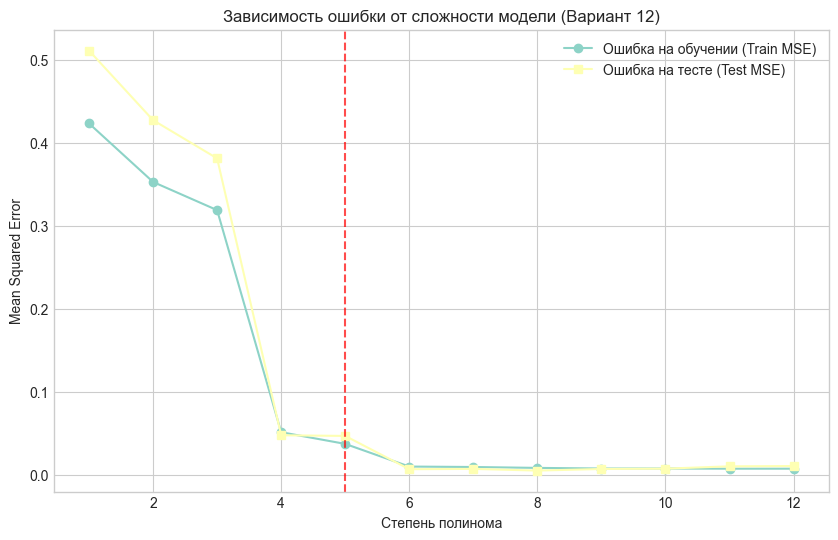

Оптимальная степень полинома (по минимуму Test MSE): 8

[Задача 2] Сравнение Ridge и Lasso регуляризации
Подбор гиперпараметра alpha методом кросс-валидации...


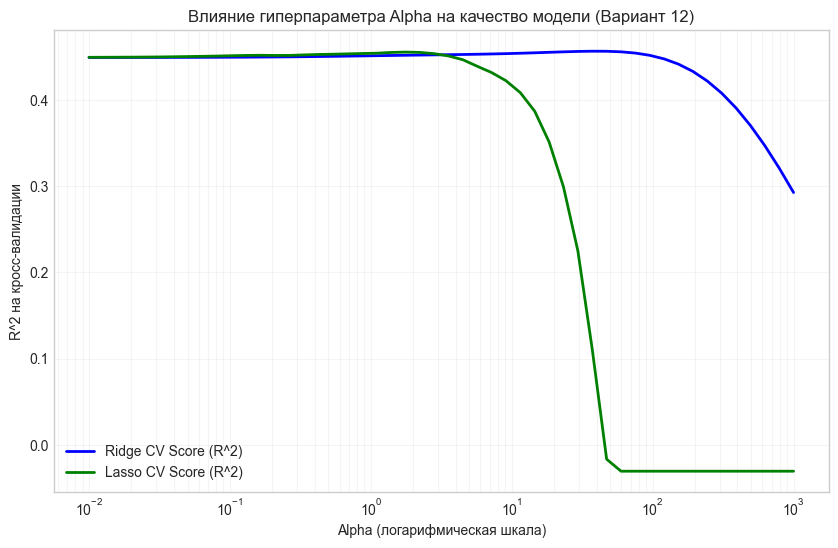

Лучшее alpha для Ridge: 37.2759, R^2: 0.4566
Лучшее alpha для Lasso: 1.7575, R^2: 0.4556

[Задача 3] Отбор признаков (Diabetes, K=5)
Топ-5 признаков по важности (Lasso):
<StringArray>
['bmi', 's5', 'bp', 's3', 'sex']
Length: 5, dtype: str

Качество модели (R^2 на тесте):
Все признаки (10): 0.4526
Отобранные признаки (5): 0.4694


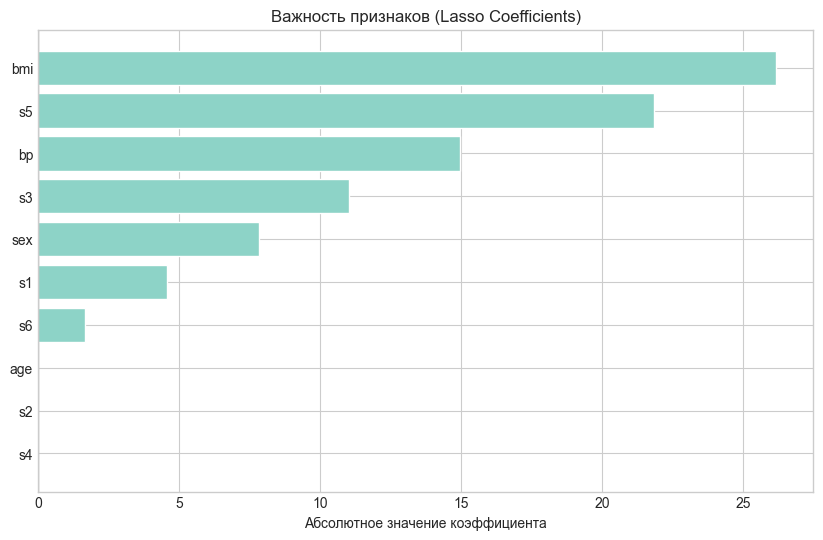


ИТОГОВЫЕ РЕЗУЛЬТАТЫ ПО ВАРИАНТУ 12
1. Оптимальная степень полинома: 8 (из диапазона 1-12)
2. Лучшая регуляризация: Ridge
3. Отбор признаков: сокращение с 10 до 5 признаков
   Потеря качества модели: -0.0168
Все эксперименты завершены.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import warnings

warnings.filterwarnings('ignore')

# Настройка стилей для графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("=" * 60)
print("Практическая работа 4: Регуляризация и Отбор Признаков")
print("Вариант 12")
print("=" * 60)

# ============================================================
# ЗАДАЧА 1: Анализ кривых обучения и переобучения
# Параметры варианта 12: степени полинома от 1 до 12
# ============================================================
print("\n[Задача 1] Анализ переобучения (Полиномиальная регрессия)")

# Генерация синтетических данных
X_syn = np.linspace(0, 10, 100).reshape(-1, 1)
y_syn = np.sin(X_syn).ravel() + np.random.normal(0, 0.1, X_syn.shape[0])

# Разделение на обучающую и тестовую выборки
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)

degrees = range(1, 13)  # Вариант 12: от 1 до 12
train_errors = []
test_errors = []

print("Вычисление ошибок для степеней полинома 1..12...")

for d in degrees:
    # Создаем пайплайн: Полином -> Масштабирование -> Регрессия
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])

    model.fit(X_train_syn, y_train_syn)

    y_train_pred = model.predict(X_train_syn)
    y_test_pred = model.predict(X_test_syn)

    train_mse = mean_squared_error(y_train_syn, y_train_pred)
    test_mse = mean_squared_error(y_test_syn, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Визуализация результатов Задачи 1
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Ошибка на обучении (Train MSE)', marker='o')
plt.plot(degrees, test_errors, label='Ошибка на тесте (Test MSE)', marker='s')
plt.xlabel('Степень полинома')
plt.ylabel('Mean Squared Error')
plt.title('Зависимость ошибки от сложности модели (Вариант 12)')
plt.legend()
plt.axvline(x=5, color='r', linestyle='--', label='Примерная оптимальная сложность', alpha=0.7)
plt.show()

# Находим оптимальную степень по минимальной ошибке на тесте
optimal_degree = degrees[np.argmin(test_errors)]
print(f"Оптимальная степень полинома (по минимуму Test MSE): {optimal_degree}")


# ============================================================
# ЗАДАЧА 2: Сравнение регуляризаторов L1 и L2
# Параметры варианта 12: диапазон поиска alpha logspace(-2, 3)
# ============================================================
print("\n[Задача 2] Сравнение Ridge и Lasso регуляризации")

# Загружаем данные Diabetes
diabetes = load_diabetes()
X_real = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_real = diabetes.target

# Разделение данных
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

# Диапазон альфа для варианта 12: от 10^-2 до 10^3
alphas = np.logspace(-2, 3, 50)

ridge_scores = []
lasso_scores = []

print("Подбор гиперпараметра alpha методом кросс-валидации...")

for alpha in alphas:
    # Ridge
    ridge_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=alpha))
    ])
    scores = cross_val_score(ridge_pipe, X_train_real, y_train_real, cv=5, scoring='r2')
    ridge_scores.append(scores.mean())

    # Lasso
    lasso_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Lasso(alpha=alpha, max_iter=10000))
    ])
    scores = cross_val_score(lasso_pipe, X_train_real, y_train_real, cv=5, scoring='r2')
    lasso_scores.append(scores.mean())

# Визуализация результатов Задачи 2
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, ridge_scores, label='Ridge CV Score (R^2)', color='blue', linewidth=2)
plt.semilogx(alphas, lasso_scores, label='Lasso CV Score (R^2)', color='green', linewidth=2)
plt.xlabel('Alpha (логарифмическая шкала)')
plt.ylabel('R^2 на кросс-валидации')
plt.title('Влияние гиперпараметра Alpha на качество модели (Вариант 12)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# Находим лучшие альфа
best_ridge_idx = np.argmax(ridge_scores)
best_lasso_idx = np.argmax(lasso_scores)

print(f"Лучшее alpha для Ridge: {alphas[best_ridge_idx]:.4f}, R^2: {ridge_scores[best_ridge_idx]:.4f}")
print(f"Лучшее alpha для Lasso: {alphas[best_lasso_idx]:.4f}, R^2: {lasso_scores[best_lasso_idx]:.4f}")


# ============================================================
# ЗАДАЧА 3: Отбор признаков на реальных данных
# Параметры варианта 12: Датасет Diabetes, K=5 признаков
# ============================================================
print("\n[Задача 3] Отбор признаков (Diabetes, K=5)")

# Используем Lasso для встроенного отбора признаков
# Сначала обучим Lasso с подобранным альфа, чтобы увидеть важность
lasso_final = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Lasso(alpha=alphas[best_lasso_idx], max_iter=10000))
])
lasso_final.fit(X_train_real, y_train_real)

coefs = lasso_final.named_steps['reg'].coef_
feature_importance = pd.DataFrame({
    'Feature': X_real.columns,
    'Coefficient': np.abs(coefs)
}).sort_values(by='Coefficient', ascending=False)

# Отбираем топ-5 признаков согласно варианту 12
top_k_features = feature_importance.head(5)['Feature'].values
print(f"Топ-{5} признаков по важности (Lasso):")
print(top_k_features)

# Обучаем модель на полных данных
full_model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])
full_model.fit(X_train_real, y_train_real)
full_score = full_model.score(X_test_real, y_test_real)

# Обучаем модель на отобранных данных
selected_model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])
selected_model.fit(X_train_real[top_k_features], y_train_real)
selected_score = selected_model.score(X_test_real[top_k_features], y_test_real)

print(f"\nКачество модели (R^2 на тесте):")
print(f"Все признаки ({len(X_real.columns)}): {full_score:.4f}")
print(f"Отобранные признаки ({len(top_k_features)}): {selected_score:.4f}")

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Абсолютное значение коэффициента')
plt.title('Важность признаков (Lasso Coefficients)')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linewidth=0.8)
plt.show()

# ============================================================
# ИТОГОВЫЕ ВЫВОДЫ
# ============================================================
print("\n" + "=" * 60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ ПО ВАРИАНТУ 12")
print("=" * 60)
print(f"1. Оптимальная степень полинома: {optimal_degree} (из диапазона 1-12)")
print(f"2. Лучшая регуляризация: {'Ridge' if ridge_scores[best_ridge_idx] > lasso_scores[best_lasso_idx] else 'Lasso'}")
print(f"3. Отбор признаков: сокращение с {len(X_real.columns)} до {len(top_k_features)} признаков")
print(f"   Потеря качества модели: {full_score - selected_score:.4f}")
print("=" * 60)
print("Все эксперименты завершены.")